# 05 - Error effects (paper Fig 7, 8, Table 3)

RT and error rate by problem (the paper's circle-grid figure), the
table-neighbor vs numeric-neighbor error classification, and the error-rate
regression against problem size.


In [1]:
# Data source toggle. The live backend DB has zero trial_results as of
# 2026-09 (see ../DATA_GAPS.md) -- this app just went public. Flip
# USE_SYNTHETIC to False once real rows exist; every cell below is written
# against the DataFrame shape returned by moravec_analysis.data, so nothing
# else needs to change.
USE_SYNTHETIC = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from moravec_analysis.data import load_trial_results
from moravec_analysis.features import add_all_derived_fields, filter_rt_outliers
from moravec_analysis.synth import generate_synthetic_trials

if USE_SYNTHETIC:
    raw = generate_synthetic_trials(n_users=400, trials_per_user=150, seed=7)
else:
    raw = load_trial_results()  # defaults to apps/backend/data/moravec.sqlite

df = add_all_derived_fields(raw)
print(f"{len(df):,} trials, {df.email_hash.nunique():,} users")
df.head()


410 trials, 1 users


,id,email_hash,level_number,category_codename,operands,answer,correct,time_exceeded,time_taken,played_at,...,has_five,op1_gt_op2,unordered_pair,presented_pair,is_rhyme_pair,presented_in_rhyme_order,is_rhyme_control_pair,presented_in_control_order,table_distance_1,numeric_distance_le_2
0,b71489e4-4089-48fb-91c8-57018effab49,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[5, 3]",8,True,False,1376,2026-09-02 14:20:30.456,...,True,True,"(3, 5)","(5, 3)",False,False,True,False,<NA>,<NA>
1,ff1c2b76-e8c9-4244-81d7-0bc393f456fa,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[4, 6]",10,True,False,1384,2026-09-02 14:20:31.840,...,False,False,"(4, 6)","(4, 6)",True,False,False,False,<NA>,<NA>
2,e69af72d-ab35-434f-8cc6-083e1554cd64,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1d+1d,"[8, 5]",13,True,False,1581,2026-09-02 14:20:33.421,...,True,True,"(5, 8)","(8, 5)",False,False,False,False,<NA>,<NA>
3,e027f4db-5f97-4e4c-af89-ee8028b725cf,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[9, 4]",36,True,False,2145,2026-09-02 14:20:35.566,...,False,True,"(4, 9)","(9, 4)",False,False,False,False,<NA>,<NA>
4,12772bbc-689d-4107-bb36-0092ee87088a,1bb8091170824093896f3bb9d158991b637d108c9b11ff...,1,1dx1d,"[7, 7]",49,True,False,1259,2026-09-02 14:20:36.825,...,False,False,"(7, 7)","(7, 7)",False,False,False,False,<NA>,<NA>


## RT and error rate per problem (paper Fig 7)

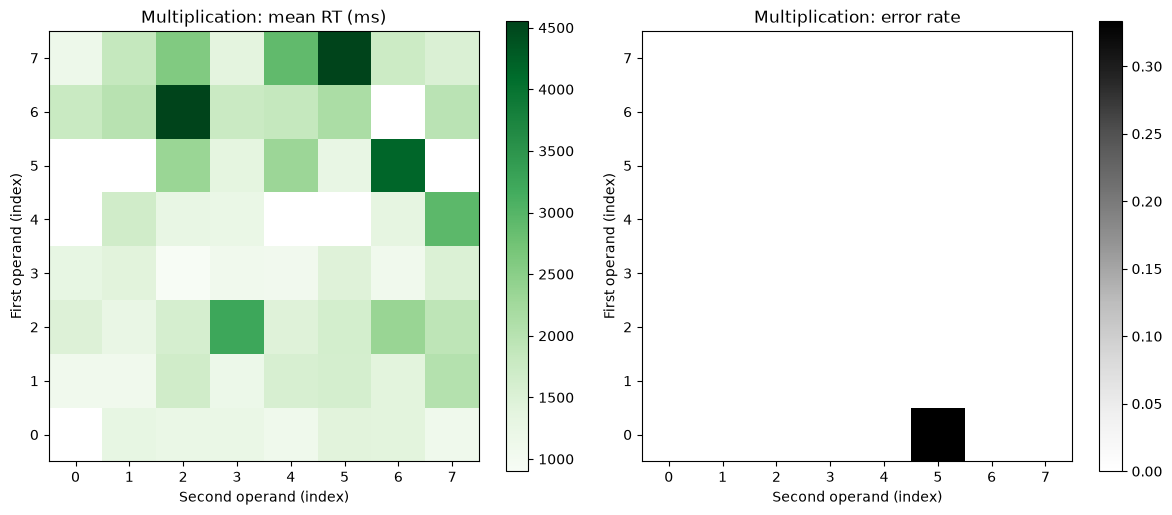

In [2]:
def problem_grid(data, category):
    sub = data[data["category_codename"] == category]
    rt = sub[sub["correct"]].groupby(["op1", "op2"])["time_taken"].mean().unstack()
    err = sub.groupby(["op1", "op2"])["correct"].apply(lambda s: 1 - s.mean()).unstack()
    return rt, err


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
rt, err = problem_grid(df, "1dx1d")
im0 = axes[0].imshow(rt, cmap="Greens", origin="lower")
axes[0].set_title("Multiplication: mean RT (ms)")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(err, cmap="Greys", origin="lower")
axes[1].set_title("Multiplication: error rate")
plt.colorbar(im1, ax=axes[1])
for ax in axes:
    ax.set_xlabel("Second operand (index)")
    ax.set_ylabel("First operand (index)")
plt.tight_layout()
plt.show()


## Table-neighbor vs numeric-neighbor errors (paper Fig 8)

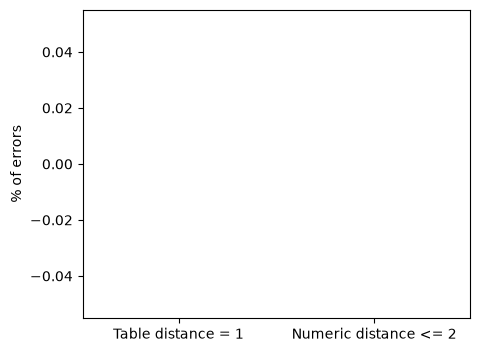

ValueError: The internally computed table of expected frequencies has a zero element at (np.int64(0), np.int64(0)).

In [3]:
wrong_mult = df[(df["category_codename"] == "1dx1d") & (~df["correct"])]
table_neighbor_rate = wrong_mult["table_distance_1"].mean()
numeric_neighbor_rate = wrong_mult["numeric_distance_le_2"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Table distance = 1", "Numeric distance <= 2"],
       [table_neighbor_rate * 100, numeric_neighbor_rate * 100],
       color=["#2a9d8f", "#e63946"])
ax.set_ylabel("% of errors")
plt.show()

from scipy.stats import chi2_contingency

contingency = pd.DataFrame({
    "table_neighbor": [wrong_mult["table_distance_1"].sum(),
                        (~wrong_mult["table_distance_1"].astype(bool)).sum()],
    "numeric_neighbor": [wrong_mult["numeric_distance_le_2"].sum(),
                          (~wrong_mult["numeric_distance_le_2"].astype(bool)).sum()],
}, index=["is", "isn't"])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"chi2={chi2:.1f}, p={p:.3g}")


## Error rate vs size (paper Table 3)

In [4]:
import statsmodels.formula.api as smf

def error_rate_model(data, category, is_tie, label):
    sub = data[(data["category_codename"] == category) & (data["is_tie"] == is_tie)].copy()
    sub["correct"] = sub["correct"].astype(int)
    model = smf.mixedlm("correct ~ product", data=sub, groups=sub["email_hash"])
    result = model.fit(reml=False)
    print(f"=== {label} ===")
    print(result.summary().tables[1].loc[["product"]])
    print()


error_rate_model(df, "1d+1d", False, "Addition, different operands")
error_rate_model(df, "1d+1d", True, "Addition, ties")
error_rate_model(df, "1dx1d", False, "Multiplication, different operands")
error_rate_model(df, "1dx1d", True, "Multiplication, ties")


/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1691: RuntimeWarning: divide by zero encountered in log
  likeval -= self.n_totobs * np.log(qf) / 2.0
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1959: RuntimeWarning: invalid value encountered in divide
  score_re += 0.5 * fac * rvavr[0 : self.k_re2] / rvir
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2384: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  rslt = super().fit(
/tmp/ipykernel_871654/2429616884.py:7: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  result = model.fit(reml=False)
/home/juancuiule/eglc-moravec/packages/analysis/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1691: RuntimeWarning: 

=== Addition, different operands ===
         Coef. Std.Err. z P>|z| [0.025 0.975]
product  0.000                               



LinAlgError: Singular matrix

Note: this models `correct` (0/1) with a linear mixed model, same as the paper's Table 3 (they regress error rate, so the sign here is flipped -- a negative `product` coefficient on `correct` corresponds to the paper's positive slope on error rate). A logistic mixed model (`smf.mixedlm` doesn't do logit; would need `statsmodels.genmod` or `GLMM` via `BinomialBayesMixedGLM`) is a closer match to how error *rates* are usually modeled -- worth revisiting once there's enough real data to care about that distinction.